# Ice Rheology: Deformation Mechanism Maps

**Ge 193 — Glacier Dynamics, Spring 2026**

This notebook generates figures for the *Ice Rheology* lecture, including deformation mechanism maps that show which creep mechanism dominates as a function of stress, temperature, and grain size.

In [1]:
# ---- Setup: imports and physical constants ----
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

R = 8.314          # J mol^{-1} K^{-1}, gas constant

# ---- Creep parameters from Goldsby & Kohlstedt (2001), Table 5 ----
# Dislocation creep (n=4, r=0)
A0_disl_cold = 4.0e5    # MPa^{-4} s^{-1}, T < 258 K
A0_disl_warm = 6.0e28   # MPa^{-4} s^{-1}, T > 258 K
n_disl = 4.0
Q_disl_cold = 60e3      # J mol^{-1}
Q_disl_warm = 181e3     # J mol^{-1}

# GBS-accommodated basal slip (n=1.8, r=1.4)
A0_gbs_cold = 3.9e-3    # MPa^{-1.8} m^{1.4} s^{-1}, T < 255 K
A0_gbs_warm = 3.0e26    # MPa^{-1.8} m^{1.4} s^{-1}, T > 255 K
n_gbs = 1.8
r_gbs = 1.4
Q_gbs_cold = 49e3       # J mol^{-1}
Q_gbs_warm = 192e3      # J mol^{-1}

# Basal-slip-accommodated GBS (n=2.4, r=0)
A0_basal = 5.5e7        # MPa^{-2.4} s^{-1}
n_basal = 2.4
Q_basal = 60e3          # J mol^{-1}

# Diffusion creep parameters (Eq. 4 of G&K 2001, Table 6)
V_m = 1.97e-5           # m^3 mol^{-1}, molar volume
D_0v = 9.10e-4          # m^2 s^{-1}, volume diffusion preexponential (Ramseier 1967)
Q_v = 59.4e3            # J mol^{-1}, volume diffusion activation energy
delta = 9.04e-10        # m, grain boundary width (= 2b, Frost & Ashby 1982)
D_0b = 8.4e-4           # m^2 s^{-1}, boundary diffusion preexponential (G&K 2001 upper bound, p. 11026)
Q_b = 49e3              # J mol^{-1}, boundary diffusion activation energy

print('Setup complete.')

Setup complete.


In [2]:
# ---- Strain-rate functions for each mechanism ----

def edot_disl(tau, T):
    """Dislocation creep strain rate. tau in MPa, T in K."""
    A0 = np.where(T < 258, A0_disl_cold, A0_disl_warm)
    Q = np.where(T < 258, Q_disl_cold, Q_disl_warm)
    return A0 * tau**n_disl * np.exp(-Q / (R * T))


def edot_gbs(tau, T, d):
    """GBS-accommodated basal slip strain rate. tau in MPa, d in m, T in K."""
    A0 = np.where(T < 255, A0_gbs_cold, A0_gbs_warm)
    Q = np.where(T < 255, Q_gbs_cold, Q_gbs_warm)
    return A0 * tau**n_gbs / d**r_gbs * np.exp(-Q / (R * T))


def edot_basal(tau, T):
    """Basal-slip-accommodated GBS strain rate. tau in MPa, T in K."""
    return A0_basal * tau**n_basal * np.exp(-Q_basal / (R * T))


def edot_diff(tau, T, d):
    """Diffusional flow strain rate (Nabarro-Herring + Coble). tau in MPa, d in m, T in K."""
    tau_Pa = tau * 1e6  # convert to Pa
    D_v = D_0v * np.exp(-Q_v / (R * T))
    D_b = D_0b * np.exp(-Q_b / (R * T))
    return 42 * tau_Pa * V_m / (R * T * d**2) * (D_v + np.pi * delta / d * D_b)


def edot_composite(tau, T, d):
    """Composite flow law (Eq. 3 of G&K 2001). tau in MPa, d in m, T in K."""
    e_diff = edot_diff(tau, T, d)
    e_basal = edot_basal(tau, T)
    e_gbs = edot_gbs(tau, T, d)
    e_disl = edot_disl(tau, T)
    # Basal slip and GBS in series, rest in parallel
    e_serial = 1.0 / (1.0 / e_basal + 1.0 / e_gbs)
    return e_diff + e_serial + e_disl


def dominant_mechanism(tau, T, d):
    """Return index of dominant mechanism: 0=diff, 1=GBS-accomm basal slip,
    2=basal-slip-accomm GBS, 3=dislocation.
    For the serial pair (basal/GBS), the dominant one is whichever has the
    lower strain rate (i.e., the rate-limiting step)."""
    e_diff = edot_diff(tau, T, d)
    e_basal = edot_basal(tau, T)
    e_gbs = edot_gbs(tau, T, d)
    e_disl = edot_disl(tau, T)
    e_serial = 1.0 / (1.0 / e_basal + 1.0 / e_gbs)
    
    # Effective contributions (parallel sum)
    rates = np.array([e_diff, e_serial, e_disl])
    parallel_dom = np.argmax(rates, axis=0)  # 0=diff, 1=serial, 2=disl
    
    # For the serial mechanism, determine which is rate-limiting
    # GBS-limited -> n=1.8 regime; basal-slip-limited -> n=2.4 regime
    gbs_limited = e_gbs <= e_basal  # GBS is slower => GBS-accommodated basal slip
    
    result = np.zeros_like(tau, dtype=int)
    result[parallel_dom == 0] = 0  # diffusion
    result[(parallel_dom == 1) & gbs_limited] = 1   # GBS-accomm basal slip (n=1.8)
    result[(parallel_dom == 1) & ~gbs_limited] = 2  # basal-slip-accomm GBS (n=2.4)
    result[parallel_dom == 2] = 3  # dislocation creep
    return result


print('Functions defined.')

Functions defined.


---
## Figure 1: Strain Rate vs. Stress (fixed $T$ and $d$)

Log-log plot of $\dot{\varepsilon}_e$ vs. $\tau_e$ showing each mechanism individually and the composite flow law. This is the most direct way to see the transitions between regimes and where $n \approx 3$ arises.

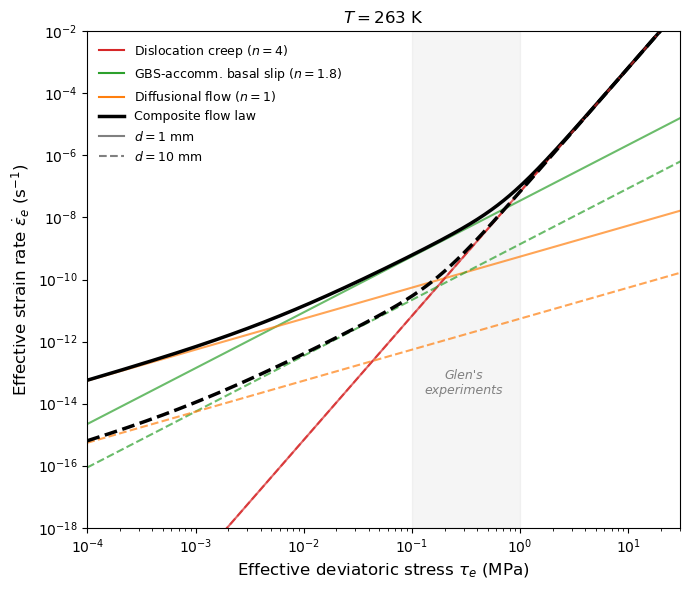

Figure 1 saved.


In [3]:
# ---- Fig 1: strain rate vs stress at two grain sizes ----
T_fig1 = 263.0   # K (about -10 C)

tau = np.logspace(-4, 1.5, 500)  # MPa

fig, ax = plt.subplots(figsize=(7, 6))

for d_val, ls, lbl_suffix in [(1e-3, '-', '1 mm'), (10e-3, '--', '10 mm')]:
    e_disl = edot_disl(tau, T_fig1)
    e_gbs = edot_gbs(tau, T_fig1, d_val)
    e_diff = edot_diff(tau, T_fig1, d_val)
    e_total = edot_composite(tau, T_fig1, d_val)

    ax.loglog(tau, e_disl, ls, color='#d62728', lw=1.5, alpha=0.7)
    ax.loglog(tau, e_gbs, ls, color='#2ca02c', lw=1.5, alpha=0.7)
    ax.loglog(tau, e_diff, ls, color='#ff7f0e', lw=1.5, alpha=0.7)
    ax.loglog(tau, e_total, ls, color='k', lw=2.5)

# Shade Glen's experimental stress range
ax.axvspan(0.1, 1.0, alpha=0.08, color='gray')
ax.text(0.3, 2e-14, "Glen's\nexperiments", fontsize=9, ha='center',
        color='gray', style='italic')

# Build legend manually: mechanism colors + line style for grain size
import matplotlib.lines as mlines
leg_disl = mlines.Line2D([], [], color='#d62728', lw=1.5, label=f'Dislocation creep ($n = {n_disl:.0f}$)')
leg_gbs = mlines.Line2D([], [], color='#2ca02c', lw=1.5, label=f'GBS-accomm. basal slip ($n = {n_gbs}$)')
leg_diff = mlines.Line2D([], [], color='#ff7f0e', lw=1.5, label='Diffusional flow ($n = 1$)')
leg_comp = mlines.Line2D([], [], color='k', lw=2.5, label='Composite flow law')
leg_d1 = mlines.Line2D([], [], color='gray', ls='-', lw=1.5, label='$d = 1$ mm')
leg_d10 = mlines.Line2D([], [], color='gray', ls='--', lw=1.5, label='$d = 10$ mm')
ax.legend(handles=[leg_disl, leg_gbs, leg_diff, leg_comp, leg_d1, leg_d10],
          loc='upper left', fontsize=9, frameon=False)

ax.set_xlabel('Effective deviatoric stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_ylabel('Effective strain rate $\\dot{\\varepsilon}_e$ (s$^{-1}$)', fontsize=12)
ax.set_xlim(1e-4, 30)
ax.set_ylim(1e-18, 1e-2)
ax.set_title(f'$T = {T_fig1:.0f}$ K', fontsize=12)

fig.tight_layout()
fig.savefig('figures/fig01_strain_rate_vs_stress.pdf', bbox_inches='tight')
fig.savefig('figures/fig01_strain_rate_vs_stress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## Figure 2: Deformation Mechanism Map — Stress vs. Temperature

For a fixed grain size, color the $\tau_e$--$T$ plane by the dominant creep mechanism. This is the classic deformation mechanism map.

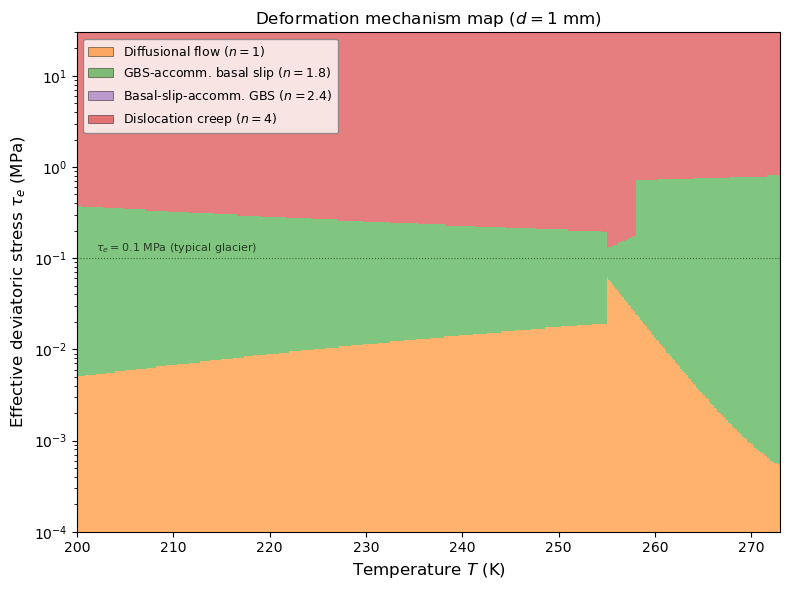

Figure 2 saved.


In [4]:
# ---- Fig 2: deformation mechanism map (stress vs temperature) ----
d_fig2 = 1e-3  # m (1 mm)

T_arr = np.linspace(200, 273, 400)
tau_arr = np.logspace(-4, 1.5, 400)
T_grid, tau_grid = np.meshgrid(T_arr, tau_arr)

dom = dominant_mechanism(tau_grid, T_grid, d_fig2)

# Colors: 0=diff (orange), 1=GBS-accomm (green), 2=basal-slip-accomm (purple), 3=disl (red)
cmap = ListedColormap(['#ff7f0e', '#2ca02c', '#9467bd', '#d62728'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(T_arr, tau_arr, dom, cmap=cmap, shading='auto', alpha=0.6)
ax.set_yscale('log')

# Legend patches
labels = ['Diffusional flow ($n=1$)',
          'GBS-accomm. basal slip ($n=1.8$)',
          'Basal-slip-accomm. GBS ($n=2.4$)',
          'Dislocation creep ($n=4$)']
colors = ['#ff7f0e', '#2ca02c', '#9467bd', '#d62728']
patches = [mpatches.Patch(facecolor=c, alpha=0.6, edgecolor='k', lw=0.5, label=l)
           for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc='upper left', fontsize=9, frameon=True,
          facecolor='white', edgecolor='gray')

# Mark typical glacier conditions
ax.axhline(0.1, color='k', ls=':', lw=0.8, alpha=0.5)
ax.text(202, 0.12, '$\\tau_e = 0.1$ MPa (typical glacier)', fontsize=8, alpha=0.7)

ax.set_xlabel('Temperature $T$ (K)', fontsize=12)
ax.set_ylabel('Effective deviatoric stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_title(f'Deformation mechanism map ($d = {d_fig2*1e3:.0f}$ mm)', fontsize=12)
ax.set_xlim(200, 273)
ax.set_ylim(1e-4, 30)

fig.tight_layout()
fig.savefig('figures/fig02_mechanism_map_stress_temp.pdf', bbox_inches='tight')
fig.savefig('figures/fig02_mechanism_map_stress_temp.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## Figure 3: Deformation Mechanism Map — Stress vs. Grain Size

At a fixed temperature, show how grain size controls the transition between grain-size-sensitive (GBS) and grain-size-insensitive (dislocation) creep.

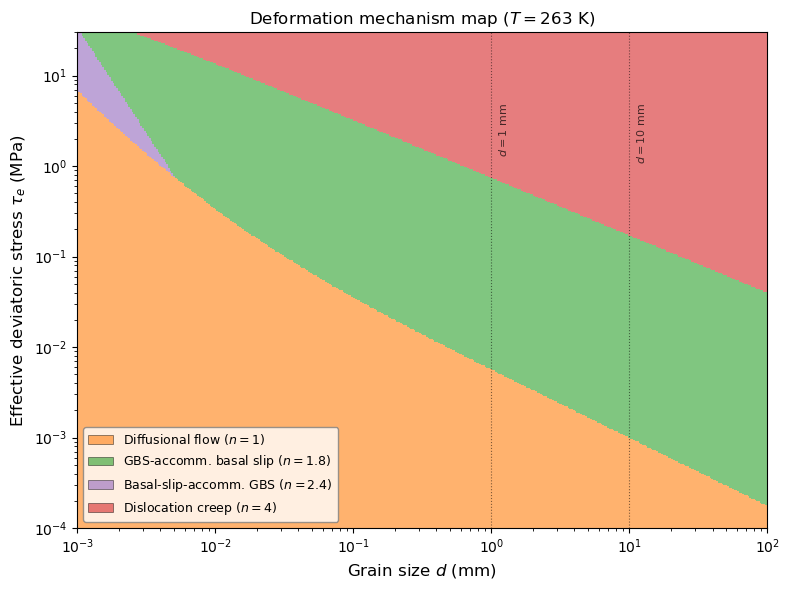

Figure 3 saved.


In [5]:
# ---- Fig 3: deformation mechanism map (stress vs grain size) ----
T_fig3 = 263.0  # K

d_arr = np.logspace(-6, -1, 400)    # m (1 um to 100 mm)
tau_arr3 = np.logspace(-4, 1.5, 400)  # MPa
d_grid, tau_grid3 = np.meshgrid(d_arr, tau_arr3)

dom3 = dominant_mechanism(tau_grid3, T_fig3, d_grid)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(d_arr * 1e3, tau_arr3, dom3, cmap=cmap, shading='auto', alpha=0.6)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(handles=patches, loc='lower left', fontsize=9, frameon=True,
          facecolor='white', edgecolor='gray')

# Mark glaciologically relevant grain sizes
ax.axvline(1.0, color='k', ls=':', lw=0.8, alpha=0.5)
ax.text(1.1, 5, '$d = 1$ mm', fontsize=8, alpha=0.7, rotation=90, va='top')
ax.axvline(10.0, color='k', ls=':', lw=0.8, alpha=0.5)
ax.text(11, 5, '$d = 10$ mm', fontsize=8, alpha=0.7, rotation=90, va='top')

ax.set_xlabel('Grain size $d$ (mm)', fontsize=12)
ax.set_ylabel('Effective deviatoric stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_title(f'Deformation mechanism map ($T = {T_fig3:.0f}$ K)', fontsize=12)
ax.set_xlim(1e-3, 100)
ax.set_ylim(1e-4, 30)

fig.tight_layout()
fig.savefig('figures/fig03_mechanism_map_stress_grain.pdf', bbox_inches='tight')
fig.savefig('figures/fig03_mechanism_map_stress_grain.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Figure 4: Effective Stress Exponent $n_{\mathrm{eff}}$

Show how the local slope of the $\log\dot{\varepsilon}_e$--$\log\tau_e$ curve varies with stress, making concrete the idea that $n = 3$ is a transitional value.

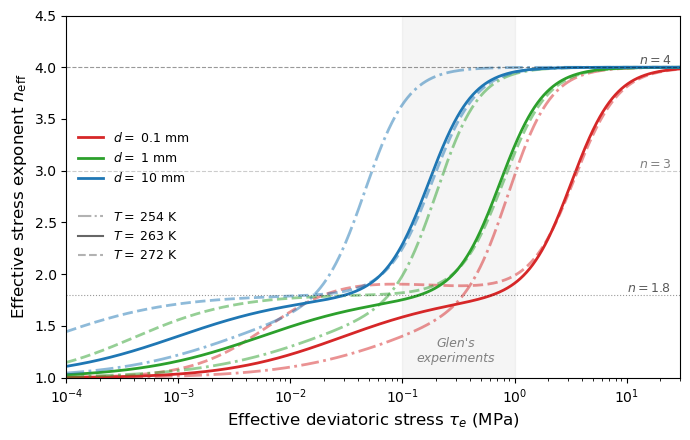

Figure 4 saved.


In [6]:
# ---- Fig 4: effective stress exponent vs stress for three grain sizes and temperatures ----
tau4 = np.logspace(-4, 1.5, 1000)
log_tau = np.log10(tau4)

grain_sizes_4 = [0.1e-3, 1e-3, 10e-3]   # m
grain_labels_4 = ['0.1 mm', '1 mm', '10 mm']
colors_4 = ['#d62728', '#2ca02c', '#1f77b4']  # tab:red, tab:green, tab:blue

temps_4 = [254.0, 263.0, 272.0]           # K
linestyles_4 = ['-.', '-', '--']
temp_labels_4 = ['254 K', '263 K', '272 K']
alphas_4 = [0.5, 1.0, 0.5]

fig, ax = plt.subplots(figsize=(7, 4.5))

for d_val, lab_d, col in zip(grain_sizes_4, grain_labels_4, colors_4):
    for T_val, ls, alph in zip(temps_4, linestyles_4, alphas_4):
        log_edot = np.log10(edot_composite(tau4, T_val, d_val))
        n_eff = np.gradient(log_edot, log_tau)
        ax.semilogx(tau4, n_eff, ls, color=col, lw=2, alpha=alph)

# Reference lines (no legend entries — use annotations instead)
ax.axhline(4.0, color='k', ls='--', lw=0.8, alpha=0.4)
ax.axhline(3.0, color='gray', ls='--', lw=0.8, alpha=0.4)
ax.axhline(1.8, color='k', ls=':', lw=0.8, alpha=0.4)

# Annotate reference lines on right side
ax.text(25, 4.0, '$n = 4$', fontsize=9, va='bottom', ha='right', color='0.35')
ax.text(25, 3.0, '$n = 3$', fontsize=9, va='bottom', ha='right', color='0.5')
ax.text(25, 1.8, '$n = 1.8$', fontsize=9, va='bottom', ha='right', color='0.35')

# Shade Glen's experimental stress range
ax.axvspan(0.1, 1.0, alpha=0.08, color='gray')
ax.text(0.3, 1.15, "Glen's\nexperiments", fontsize=9, ha='center',
        color='gray', style='italic')

# Legend: grain size (color) and temperature (linestyle)
import matplotlib.lines as mlines
handles = []
for lab_d, col in zip(grain_labels_4, colors_4):
    handles.append(mlines.Line2D([], [], color=col, lw=2, ls='-', label=f'$d = $ {lab_d}'))
handles.append(mlines.Line2D([], [], color='gray', lw=0, label=''))  # spacer
for lab_t, ls, alph in zip(temp_labels_4, linestyles_4, alphas_4):
    handles.append(mlines.Line2D([], [], color='0.4', lw=1.5, ls=ls, alpha=alph, label=f'$T = $ {lab_t}'))

ax.legend(handles=handles, loc='center left', fontsize=9, frameon=False)

ax.set_xlabel('Effective deviatoric stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_ylabel('Effective stress exponent $n_{\\mathrm{eff}}$', fontsize=12)
ax.set_xlim(1e-4, 30)
ax.set_ylim(1.0, 4.5)

fig.tight_layout()
fig.savefig('figures/fig04_effective_n_vs_stress.pdf', bbox_inches='tight')
fig.savefig('figures/fig04_effective_n_vs_stress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Figure 5: Effect of Grain Size on the Composite Flow Law

Show how grain size shifts the transition between GBS-dominated and dislocation-dominated flow.

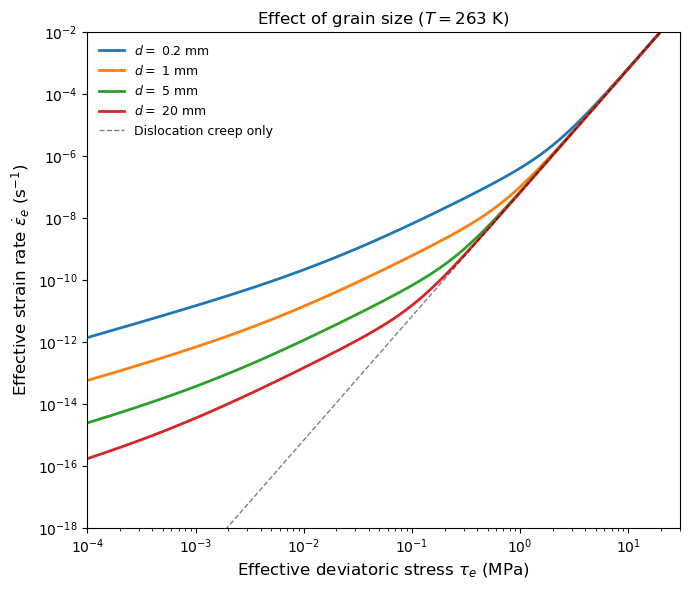

Figure 5 saved.


In [7]:
# ---- Fig 5: composite flow law for different grain sizes ----
T_fig5 = 263.0
tau5 = np.logspace(-4, 1.5, 500)

grain_sizes = [0.2e-3, 1e-3, 5e-3, 20e-3]  # m
grain_labels = ['0.2 mm', '1 mm', '5 mm', '20 mm']
colors5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(7, 6))

for d_val, lab, col in zip(grain_sizes, grain_labels, colors5):
    e_total = edot_composite(tau5, T_fig5, d_val)
    ax.loglog(tau5, e_total, '-', color=col, lw=2, label=f'$d = $ {lab}')

# Dislocation creep (grain-size independent) for reference
ax.loglog(tau5, edot_disl(tau5, T_fig5), 'k--', lw=1, alpha=0.5,
          label='Dislocation creep only')

ax.set_xlabel('Effective deviatoric stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_ylabel('Effective strain rate $\\dot{\\varepsilon}_e$ (s$^{-1}$)', fontsize=12)
ax.set_xlim(1e-4, 30)
ax.set_ylim(1e-18, 1e-2)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.set_title(f'Effect of grain size ($T = {T_fig5:.0f}$ K)', fontsize=12)

fig.tight_layout()
fig.savefig('figures/fig05_grain_size_effect.pdf', bbox_inches='tight')
fig.savefig('figures/fig05_grain_size_effect.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

---
## Figure 6: Effective Stress Exponent at Glen's Experimental Conditions

Show $n_{\mathrm{eff}}$ vs. $\tau_e$ at $T = 271$ K and $d = 2$ mm (Glen's conditions), with the crossover stress $\tau_e^*$ and the five worked-example points marked.

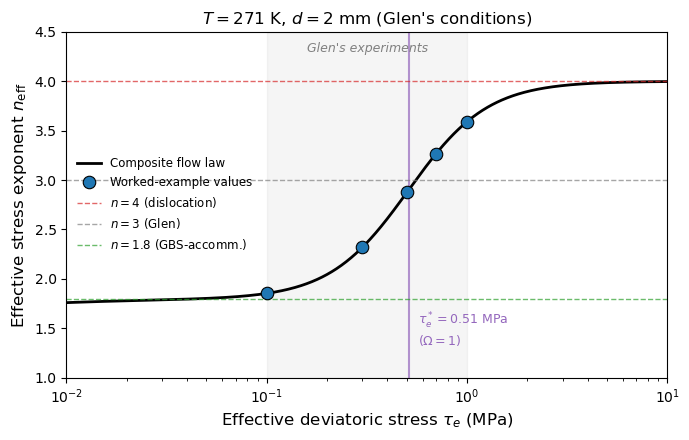

Figure 6 saved.


In [8]:
# ---- Fig 6: n_eff at Glen's experimental conditions (T=271 K, d=2 mm) ----
T_fig6 = 271.0   # K (near melting, Glen's conditions)
d_fig6 = 2e-3    # m (2 mm)

tau6 = np.logspace(-2, 1.0, 1000)
log_tau6 = np.log10(tau6)
log_edot6 = np.log10(edot_composite(tau6, T_fig6, d_fig6))

# Numerical derivative: n_eff = d(log edot) / d(log tau)
n_eff6 = np.gradient(log_edot6, log_tau6)

# Crossover stress from the worked example
tau_star = 0.51  # MPa

# Worked-example points
tau_pts = np.array([0.1, 0.3, 0.5, 0.7, 1.0])
R_pts = (tau_pts / tau_star)**2.2
n_eff_pts = (1.8 + 4.0 * R_pts) / (1.0 + R_pts)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogx(tau6, n_eff6, 'k-', lw=2, label='Composite flow law')
ax.plot(tau_pts, n_eff_pts, 'o', color='#1f77b4', ms=9, zorder=5,
        markeredgecolor='k', markeredgewidth=0.8, label='Worked-example values')

# Crossover stress
ax.axvline(tau_star, color='#9467bd', ls='-', lw=1.5, alpha=0.7)
ax.text(tau_star * 1.12, 1.3, f'$\\tau_e^* = {tau_star}$ MPa\n($\\Omega = 1$)',
        fontsize=9, color='#9467bd', va='bottom')

# Reference lines
ax.axhline(4.0, color='#d62728', ls='--', lw=1, alpha=0.7, label='$n = 4$ (dislocation)')
ax.axhline(3.0, color='gray', ls='--', lw=1, alpha=0.7, label='$n = 3$ (Glen)')
ax.axhline(1.8, color='#2ca02c', ls='--', lw=1, alpha=0.7, label='$n = 1.8$ (GBS-accomm.)')

# Shade Glen's experimental stress range
ax.axvspan(0.1, 1.0, alpha=0.08, color='gray')
ax.text(0.32, 4.3, "Glen's experiments", fontsize=9, ha='center',
        color='gray', style='italic')

ax.set_xlabel('Effective deviatoric stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_ylabel('Effective stress exponent $n_{\\mathrm{eff}}$', fontsize=12)
ax.set_xlim(0.01, 10)
ax.set_ylim(1.0, 4.5)
ax.legend(loc='center left', fontsize=8.5, frameon=False)
ax.set_title(f'$T = {T_fig6:.0f}$ K, $d = {d_fig6*1e3:.0f}$ mm (Glen\'s conditions)', fontsize=12)

fig.tight_layout()
fig.savefig('figures/fig06_n_eff_glen_conditions.pdf', bbox_inches='tight')
fig.savefig('figures/fig06_n_eff_glen_conditions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## Figure 7: Velocity Sensitivity to the Creep Exponent

Two-panel figure showing how the surface velocity responds to changes in thickness and slope as a function of $n$.

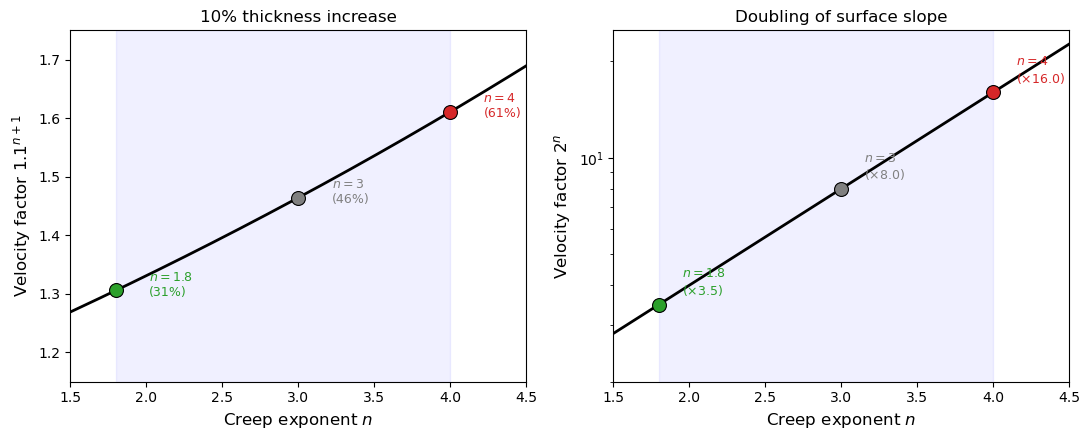

Figure 7 saved.


In [9]:
# ---- Fig 7: velocity sensitivity to n (two panels) ----
n_range = np.linspace(1.5, 4.5, 200)

# Left panel: 10% thickness increase -> velocity factor = 1.1^(n+1)
thickness_factor = 1.1**(n_range + 1)

# Right panel: doubling slope -> velocity factor = 2^n
slope_factor = 2.0**n_range

# Specific n values to mark
n_marks = np.array([1.8, 3.0, 4.0])
n_labels = ['1.8', '3', '4']
colors_marks = ['#2ca02c', 'gray', '#d62728']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# -- Left panel: thickness sensitivity --
ax1.plot(n_range, thickness_factor, 'k-', lw=2)
ax1.axvspan(1.8, 4.0, alpha=0.06, color='blue')
for nv, lab, col in zip(n_marks, n_labels, colors_marks):
    yv = 1.1**(nv + 1)
    ax1.plot(nv, yv, 'o', color=col, ms=10, zorder=5,
             markeredgecolor='k', markeredgewidth=0.8)
    pct = (yv - 1) * 100
    ax1.annotate(f'$n = {lab}$\n({pct:.0f}%)',
                 xy=(nv, yv), xytext=(nv + 0.22, yv + 0.01),
                 fontsize=9, ha='left', va='center', color=col)

ax1.set_xlabel('Creep exponent $n$', fontsize=12)
ax1.set_ylabel('Velocity factor $1.1^{n+1}$', fontsize=12)
ax1.set_title('10% thickness increase', fontsize=12)
ax1.set_xlim(1.5, 4.5)
ax1.set_ylim(1.15, 1.75)

# -- Right panel: slope sensitivity --
ax2.plot(n_range, slope_factor, 'k-', lw=2)
ax2.axvspan(1.8, 4.0, alpha=0.06, color='blue')
for nv, lab, col in zip(n_marks, n_labels, colors_marks):
    yv = 2.0**nv
    ax2.plot(nv, yv, 'o', color=col, ms=10, zorder=5,
             markeredgecolor='k', markeredgewidth=0.8)
    ax2.annotate(f'$n = {lab}$\n($\\times${yv:.1f})',
                 xy=(nv, yv), xytext=(nv + 0.15, yv * 1.05),
                 fontsize=9, ha='left', va='bottom', color=col)

ax2.set_xlabel('Creep exponent $n$', fontsize=12)
ax2.set_ylabel('Velocity factor $2^n$', fontsize=12)
ax2.set_title('Doubling of surface slope', fontsize=12)
ax2.set_xlim(1.5, 4.5)
ax2.set_yscale('log')
ax2.set_ylim(2, 25)

fig.tight_layout()
fig.savefig('figures/fig07_velocity_sensitivity.pdf', bbox_inches='tight')
fig.savefig('figures/fig07_velocity_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

---
## Figure 8: Velocity Prediction Ratio — Glen's Law vs. Composite Flow Law

Show the ratio $u_s^{\mathrm{Glen}}/u_s^{\mathrm{composite}}$ as a function of basal shear stress, assuming both laws are calibrated at $\tau_{\mathrm{ref}} = 0.3$ MPa. This quantifies how much Glen's law over- or underpredicts velocities away from the calibration stress.

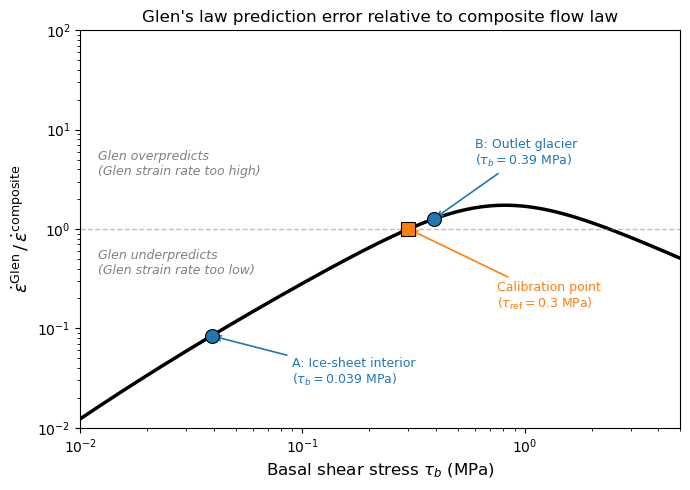

Figure 8 saved.


In [10]:
# ---- Fig 8: velocity ratio Glen/composite vs basal shear stress ----
# Use T=263 K, d=1 mm as a representative ice-sheet condition for the composite law.
T_fig8 = 263.0
d_fig8 = 1e-3

tau_ref = 0.3  # MPa, calibration stress
n_glen = 3.0

tau8 = np.logspace(-2, 0.7, 500)  # MPa

# Composite strain rate at each stress
edot_comp = edot_composite(tau8, T_fig8, d_fig8)
edot_comp_ref = edot_composite(np.array([tau_ref]), T_fig8, d_fig8)[0]

# Glen strain rate, calibrated to match composite at tau_ref
# Glen: edot = edot_ref * (tau/tau_ref)^3
edot_glen = edot_comp_ref * (tau8 / tau_ref)**n_glen

# Ratio of Glen to composite strain rates
ratio = edot_glen / edot_comp

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(tau8, ratio, 'k-', lw=2.5)
ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)

# Mark the two glaciological settings
settings = [
    (0.039, 'A: Ice-sheet interior\n($\\tau_b = 0.039$ MPa)'),
    (0.39,  'B: Outlet glacier\n($\\tau_b = 0.39$ MPa)'),
]
for tau_s, label in settings:
    edot_g = edot_comp_ref * (tau_s / tau_ref)**n_glen
    edot_c = edot_composite(np.array([tau_s]), T_fig8, d_fig8)[0]
    r = edot_g / edot_c
    ax.plot(tau_s, r, 'o', color='#1f77b4', ms=10, zorder=5,
            markeredgecolor='k', markeredgewidth=0.8)

# Annotate Setting A (low stress, below the curve)
edot_g_A = edot_comp_ref * (0.039 / tau_ref)**n_glen
edot_c_A = edot_composite(np.array([0.039]), T_fig8, d_fig8)[0]
r_A = edot_g_A / edot_c_A
ax.annotate('A: Ice-sheet interior\n($\\tau_b = 0.039$ MPa)',
            xy=(0.039, r_A), xytext=(0.09, 0.025),
            fontsize=9, ha='left', va='bottom', color='#1f77b4',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.2))

# Annotate Setting B (near crossover)
edot_g_B = edot_comp_ref * (0.39 / tau_ref)**n_glen
edot_c_B = edot_composite(np.array([0.39]), T_fig8, d_fig8)[0]
r_B = edot_g_B / edot_c_B
ax.annotate('B: Outlet glacier\n($\\tau_b = 0.39$ MPa)',
            xy=(0.39, r_B), xytext=(0.6, 4.0),
            fontsize=9, ha='left', va='bottom', color='#1f77b4',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.2))

# Mark calibration point
ax.plot(tau_ref, 1.0, 's', color='#ff7f0e', ms=10, zorder=5,
        markeredgecolor='k', markeredgewidth=0.8)
ax.annotate('Calibration point\n($\\tau_{\\mathrm{ref}} = 0.3$ MPa)',
            xy=(tau_ref, 1.0), xytext=(tau_ref * 2.5, 0.3),
            fontsize=9, ha='left', va='top', color='#ff7f0e',
            arrowprops=dict(arrowstyle='->', color='#ff7f0e', lw=1.2))

# Labels indicating over/underprediction (ratio>1 means Glen overpredicts)
ax.text(0.012, 3.5, 'Glen overpredicts\n(Glen strain rate too high)', fontsize=9,
        color='gray', style='italic', ha='left')
ax.text(0.012, 0.35, 'Glen underpredicts\n(Glen strain rate too low)', fontsize=9,
        color='gray', style='italic', ha='left')

ax.set_xlabel('Basal shear stress $\\tau_b$ (MPa)', fontsize=12)
ax.set_ylabel('$\\dot{\\varepsilon}^{\\mathrm{Glen}} \\,/\\, '
              '\\dot{\\varepsilon}^{\\mathrm{composite}}$', fontsize=13)
ax.set_title('Glen\'s law prediction error relative to composite flow law', fontsize=12)
ax.set_xlim(0.01, 5)
ax.set_ylim(0.01, 100)

fig.tight_layout()
fig.savefig('figures/fig08_velocity_ratio.pdf', bbox_inches='tight')
fig.savefig('figures/fig08_velocity_ratio.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

---
## Figure 9: The Crossover Stress as a Stress Attractor

Compute the steady-state basal shear stress as a function of specific flux $q = \dot{b} L$ for the composite flow law. For a slab on a slope with no sliding:

$$q = 2\int_0^h \dot{\varepsilon}_{\mathrm{composite}}\!\bigl(\rho_i g \zeta \sin\alpha\bigr)\;\zeta\;\mathrm{d}\zeta$$

where $\zeta$ is depth below the surface and $h = \tau_b / (\rho_i g \sin\alpha)$. For each $\tau_b$, we evaluate this integral numerically and plot $\tau_b$ vs. $q$.

/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_45452/1437192177.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2.0 * np.trapz(integrand, zeta)


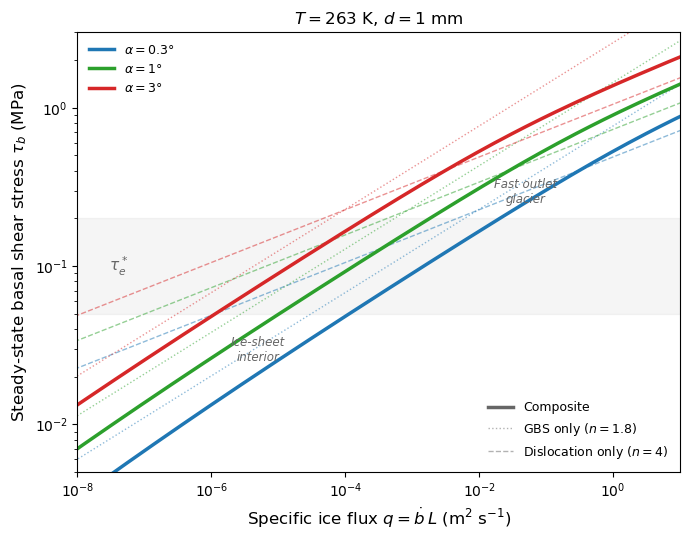

Figure 9 saved.


In [11]:
# ---- Fig 9: stress attractor — steady-state tau_b vs specific flux ----
from scipy import integrate

rho_i = 917.0   # kg m^{-3}
g = 9.8          # m s^{-2}

T_fig9 = 263.0   # K
d_fig9 = 1e-3    # m (1 mm)

def flux_composite(tau_b, alpha_rad, T, d_grain, npts=500):
    """Compute depth-integrated specific flux q for the composite flow law.
    q = 2 * integral_0^h edot_composite(rho_i g zeta sin(alpha)) * zeta dzeta
    where h = tau_b / (rho_i g sin(alpha)).
    tau_b in MPa.
    """
    sin_a = np.sin(alpha_rad)
    h = (tau_b * 1e6) / (rho_i * g * sin_a)   # thickness in m
    zeta = np.linspace(0, h, npts)              # depth below surface, m
    tau_z = rho_i * g * zeta * sin_a * 1e-6     # stress in MPa
    tau_z[0] = 1e-12  # avoid zero stress
    edot_z = edot_composite(tau_z, T, d_grain)
    integrand = edot_z * zeta
    return 2.0 * np.trapz(integrand, zeta)

def flux_power_law(tau_b, alpha_rad, A_val, n_val):
    """Analytic flux for a single power law: q = 2A/(n+2) * (rho_i g sin a)^n * h^(n+2).
    tau_b in MPa, A_val in MPa^{-n} s^{-1}.
    """
    sin_a = np.sin(alpha_rad)
    h = (tau_b * 1e6) / (rho_i * g * sin_a)
    return (2 * A_val / (n_val + 2)) * (rho_i * g * sin_a * 1e-6)**n_val * h**(n_val + 2)

# Effective A for each mechanism at T_fig9
A_gbs_eff = A0_gbs_cold * np.exp(-Q_gbs_cold / (R * T_fig9)) / d_fig9**r_gbs  # MPa^{-1.8} s^{-1}
A_disl_eff = A0_disl_cold * np.exp(-Q_disl_cold / (R * T_fig9))               # MPa^{-4} s^{-1}

slopes_deg = [0.3, 1.0, 3.0]
slope_labels = ['$\\alpha = 0.3°$', '$\\alpha = 1°$', '$\\alpha = 3°$']
slope_colors = ['#1f77b4', '#2ca02c', '#d62728']

tau_b_arr = np.logspace(-2.5, 0.5, 200)  # MPa

fig, ax = plt.subplots(figsize=(7, 5.5))

for alpha_deg, lab, col in zip(slopes_deg, slope_labels, slope_colors):
    alpha_rad = np.radians(alpha_deg)

    # Composite flow law (numerical)
    q_comp = np.array([flux_composite(tb, alpha_rad, T_fig9, d_fig9) for tb in tau_b_arr])

    # Individual mechanisms (analytic)
    q_gbs = np.array([flux_power_law(tb, alpha_rad, A_gbs_eff, 1.8) for tb in tau_b_arr])
    q_disl = np.array([flux_power_law(tb, alpha_rad, A_disl_eff, 4.0) for tb in tau_b_arr])

    ax.loglog(q_comp, tau_b_arr, '-', color=col, lw=2.5, label=lab)
    ax.loglog(q_gbs, tau_b_arr, ':', color=col, lw=1, alpha=0.5)
    ax.loglog(q_disl, tau_b_arr, '--', color=col, lw=1, alpha=0.5)

# Crossover stress band
ax.axhspan(0.05, 0.2, alpha=0.08, color='gray')
ax.text(3e-8, 0.10, '$\\tau_e^*$', fontsize=11, ha='left', va='center',
        color='0.4', style='italic')

# Reference flux values
# Ice-sheet interior: b ~ 0.1 m/yr, L ~ 500 km -> q ~ 5e4 m^2/yr ~ 1.6e-3 m^2/s
# Fast outlet: b ~ 0.5 m/yr, L ~ 200 km -> q ~ 1e5 m^2/yr ~ 3.2e-3 m^2/s
# But let's mark approximate ranges
ax.annotate('Ice-sheet\ninterior', xy=(5e-6, 0.025), fontsize=8.5, ha='center',
            color='0.4', style='italic')
ax.annotate('Fast outlet\nglacier', xy=(5e-2, 0.25), fontsize=8.5, ha='center',
            color='0.4', style='italic')

# Legend for line styles
import matplotlib.lines as mlines
handles_slope = [mlines.Line2D([], [], color=c, lw=2.5, label=l)
                 for c, l in zip(slope_colors, slope_labels)]
handles_style = [
    mlines.Line2D([], [], color='0.4', lw=2.5, ls='-', label='Composite'),
    mlines.Line2D([], [], color='0.4', lw=1, ls=':', alpha=0.5, label='GBS only ($n = 1.8$)'),
    mlines.Line2D([], [], color='0.4', lw=1, ls='--', alpha=0.5, label='Dislocation only ($n = 4$)'),
]
leg1 = ax.legend(handles=handles_slope, loc='upper left', fontsize=9, frameon=False)
ax.add_artist(leg1)
ax.legend(handles=handles_style, loc='lower right', fontsize=9, frameon=False)

ax.set_xlabel('Specific ice flux $q = \\dot{b}\\,L$ (m$^2$ s$^{-1}$)', fontsize=12)
ax.set_ylabel('Steady-state basal shear stress $\\tau_b$ (MPa)', fontsize=12)
ax.set_title(f'$T = {T_fig9:.0f}$ K, $d = {d_fig9*1e3:.0f}$ mm', fontsize=12)
ax.set_xlim(1e-8, 1e1)
ax.set_ylim(0.005, 3)

fig.tight_layout()
fig.savefig('figures/fig09_stress_attractor.pdf', bbox_inches='tight')
fig.savefig('figures/fig09_stress_attractor.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

---
## Figure 10: Marine Ice Sheet Instability and the Stress Exponent

Reproduce the qualitative result from Ranganathan & Minchew (2024, Fig. 1B), following Schoof (2007): the grounding line flux $q_g \propto h_g^{\gamma(n)}$ with $\gamma(n) = 2(n+1)(n+3)/(2n+3)$ intersects the accumulation line $q = \dot{b}\,x_g$ at steady-state grounding line positions. For $n = 3$, an unstable steady state exists on the retrograde bed slope (MISI). For $n = 1.8$ and $n = 4$ with corresponding $A$ values from the composite flow law, all steady states are stable.

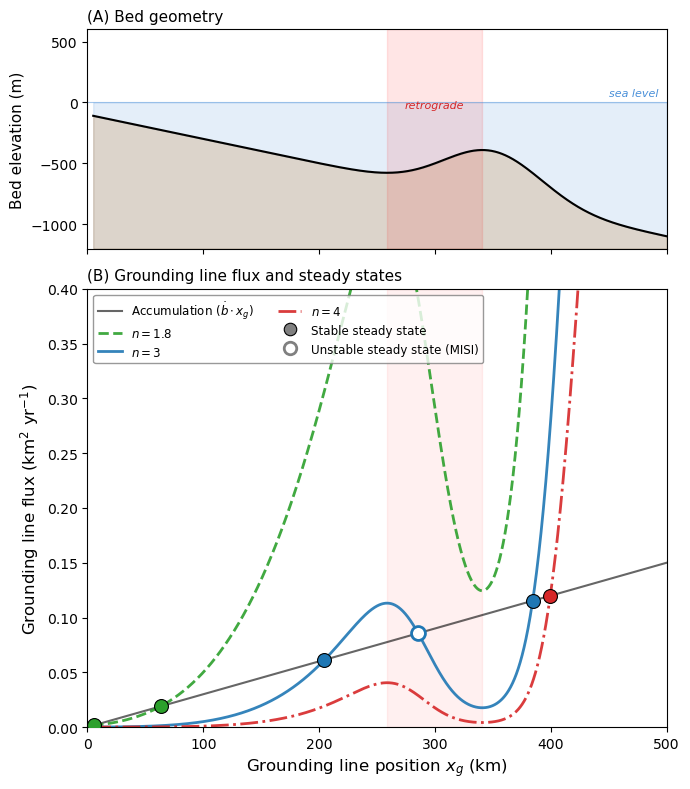

Figure 10 saved.


In [12]:
# ---- Fig 10: MISI and the stress exponent ----
# Following Schoof (2007, JGR) and Ranganathan & Minchew (2024, PNAS, Fig 1B).
#
# Schoof (2007) Eq. 16 gives the grounding line flux as:
#   q_g = Lambda(A, n, C) * h_g^{gamma(n, m)}
# where gamma(n, m) = (mn + 3m + 1) / (m + 1) in the dynamics lecture convention
# u_b = C tau_b^m, with m = n a common choice.

rho_i_fig10 = 917.0
rho_w_fig10 = 1028.0
g_fig10 = 9.8
f_fig10 = rho_i_fig10 / rho_w_fig10

# ---- Bed geometry: linear slope + Gaussian sill ----
x_km = np.linspace(5, 500, 3000)
x_m = x_km * 1e3

b = -100 - 2.0 * x_km + 400 * np.exp(-((x_km - 350) / 60)**2)

# Flotation thickness (m), only where bed is below sea level
h_f = np.where(b < 0, rho_w_fig10 / rho_i_fig10 * (-b), 0.0)

# ---- Accumulation ----
b_dot = 0.3  # m/yr
q_acc = b_dot * x_m  # m^2/yr

# ---- Schoof flux for three n values ----
# gamma(n, m) = (mn + 3m + 1) / (m + 1) with m = n (dynamics convention)
gamma_fn = lambda n: (n*n + 3*n + 1) / (n + 1)

# K(n) values chosen so that:
#   - n=1.8: high K (high A from GBS regime) -> stays ABOVE accumulation on retrograde
#   - n=3: intermediate K -> crosses accumulation on retrograde (MISI)
#   - n=4: low K (low A from dislocation regime) -> stays BELOW accumulation on retrograde
K_vals = {1.8: 1.0e-4, 3.0: 5.0e-9, 4.0: 2.0e-12}

n_vals = [1.8, 3.0, 4.0]
colors_misi = {'1.8': '#2ca02c', '3.0': '#1f77b4', '4.0': '#d62728'}
lstyles = {'1.8': '--', '3.0': '-', '4.0': '-.'}
labels_n = {'1.8': '$n = 1.8$', '3.0': '$n = 3$', '4.0': '$n = 4$'}

fig, (ax_bed, ax_flux) = plt.subplots(2, 1, figsize=(7, 8),
                                       gridspec_kw={'height_ratios': [1, 2]},
                                       sharex=True)

# ---- Panel A: Bed geometry ----
ax_bed.fill_between(x_km, b, -1200, color='#8B7355', alpha=0.3, label='Bed')
ax_bed.plot(x_km, b, 'k-', lw=1.5)
ax_bed.axhline(0, color='#4a90d9', ls='-', lw=0.8, alpha=0.5)
ax_bed.fill_between(x_km, np.minimum(b, 0), 0, color='#4a90d9', alpha=0.15)

# Shade retrograde section
db_dx = np.gradient(b, x_km)
retro_mask = db_dx > 0
retro_x = x_km[retro_mask]
if len(retro_x) > 0:
    ax_bed.axvspan(retro_x[0], retro_x[-1], alpha=0.10, color='red')
    ax_bed.text(0.5 * (retro_x[0] + retro_x[-1]), -50, 'retrograde',
                fontsize=8, ha='center', color='#d62728', style='italic')

ax_bed.set_ylabel('Bed elevation (m)', fontsize=11)
ax_bed.set_ylim(-1200, 600)
ax_bed.set_title('(A) Bed geometry', fontsize=11, loc='left')
ax_bed.text(450, 50, 'sea level', fontsize=8, color='#4a90d9', style='italic')

# ---- Panel B: Grounding line flux vs position ----
ax_flux.plot(x_km, q_acc / 1e6, 'k-', lw=1.5, alpha=0.6, label='Accumulation ($\\dot{b} \\cdot x_g$)')

for n_val in n_vals:
    key = f'{n_val}'
    gamma = gamma_fn(n_val)
    K = K_vals[n_val]
    q_g = K * h_f**gamma  # m^2/yr

    ax_flux.plot(x_km, q_g / 1e6, lstyles[key], color=colors_misi[key],
                 lw=2, label=labels_n[key], alpha=0.9)

    # Find intersections with accumulation line
    diff = q_g - q_acc
    sign_changes = np.where(np.diff(np.sign(diff)))[0]

    for idx in sign_changes:
        x_cross = x_km[idx] + (x_km[idx+1] - x_km[idx]) * (-diff[idx]) / (diff[idx+1] - diff[idx])
        q_cross = b_dot * x_cross * 1e3 / 1e6

        db_at_cross = np.interp(x_cross, x_km, db_dx)
        is_retrograde = db_at_cross > 0.1

        if is_retrograde:
            ax_flux.plot(x_cross, q_cross, 'o', color=colors_misi[key], ms=10,
                         markerfacecolor='white', markeredgewidth=2, zorder=5)
        else:
            ax_flux.plot(x_cross, q_cross, 'o', color=colors_misi[key], ms=10,
                         markeredgecolor='k', markeredgewidth=0.8, zorder=5)

if len(retro_x) > 0:
    ax_flux.axvspan(retro_x[0], retro_x[-1], alpha=0.06, color='red')

ax_flux.plot([], [], 'o', color='gray', ms=9, markeredgecolor='k',
             markeredgewidth=0.8, label='Stable steady state')
ax_flux.plot([], [], 'o', color='gray', ms=9, markerfacecolor='white',
             markeredgewidth=2, label='Unstable steady state (MISI)')

ax_flux.set_xlabel('Grounding line position $x_g$ (km)', fontsize=12)
ax_flux.set_ylabel('Grounding line flux (km$^2$ yr$^{-1}$)', fontsize=12)
ax_flux.set_xlim(0, 500)
ax_flux.set_ylim(0, 0.4)
ax_flux.legend(loc='upper left', fontsize=8.5, frameon=True, facecolor='white',
               edgecolor='gray', ncol=2)
ax_flux.set_title('(B) Grounding line flux and steady states', fontsize=11, loc='left')

fig.tight_layout()
fig.savefig('figures/fig10_misi_stability.pdf', bbox_inches='tight')
fig.savefig('figures/fig10_misi_stability.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 10 saved.')